In [2]:
import sys
sys.path.append("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 20) # tomo solo las 1000 primeras imágenes
subdataset_processed = CTManager.process_batch(subdataset)
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)

Cargando subconjunto de datos (Primeras 20 imágenes)...
  -> Cargado subconjunto Bleeding: (20, 512, 512)
  -> Cargado subconjunto Ischemia: (20, 512, 512)
  -> Cargado subconjunto Normal: (20, 512, 512)
Iniciando extracción de cerebros...
  -> Procesando clase: Bleeding (20 imágenes)
  -> Procesando clase: Ischemia (20 imágenes)
  -> Procesando clase: Normal (20 imágenes)
Extracción completada.


### Definición de función analyze_overlay_sizes(dataset)

In [4]:
def analyze_overlay_sizes(dataset):
    """
    Analiza el tamaño de las lesiones en las máscaras de Bleeding e Ischemia.
    Calcula el alto y ancho de la región que contiene la lesión.
    """
    lesion_stats = {'Bleeding': {'h': [], 'w': []}, 'Ischemia': {'h': [], 'w': []}}
    
    print("-" * 50)
    print("ANÁLISIS DE TAMAÑOS DE OVERLAY (Bounding Boxes)")
    print("-" * 50)

    for cls in ['Bleeding', 'Ischemia']:
        if cls not in dataset or dataset[cls] is None:
            continue
            
        for mask in dataset[cls]['overlay']:
            # Buscamos cualquier pixel que pertenezca a la máscara (> 0)
            y_indices, x_indices = np.where(mask > 0)
            
            if len(y_indices) > 0:
                # Calculamos el alto y ancho de la caja que encierra la lesión
                height = y_indices.max() - y_indices.min() + 1
                width = x_indices.max() - x_indices.min() + 1
                
                lesion_stats[cls]['h'].append(height)
                lesion_stats[cls]['w'].append(width)

        # Calculamos y mostramos percentiles para tomar decisiones realistas
        h_arr = np.array(lesion_stats[cls]['h'])
        w_arr = np.array(lesion_stats[cls]['w'])
        
        if len(h_arr) > 0:
            print(f"\nClase: {cls} ({len(h_arr)} lesiones válidas)")
            print(f"  - Alto (H) -> Min: {h_arr.min()}px | Media: {int(h_arr.mean())}px | Max: {h_arr.max()}px")
            print(f"  - Ancho (W)-> Min: {w_arr.min()}px | Media: {int(w_arr.mean())}px | Max: {w_arr.max()}px")
            print(f"  * El 10% de las lesiones miden MENOS de: {int(np.percentile(h_arr, 10))}x{int(np.percentile(w_arr, 10))} px")
            print(f"  * El 50% de las lesiones miden MENOS de: {int(np.percentile(h_arr, 50))}x{int(np.percentile(w_arr, 50))} px")

    # Ploteo de la distribución
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Distribución de Tamaños de Lesiones (Ancho x Alto)", fontsize=14)
    
    for idx, cls in enumerate(['Bleeding', 'Ischemia']):
        if len(lesion_stats[cls]['h']) > 0:
            axes[idx].scatter(lesion_stats[cls]['w'], lesion_stats[cls]['h'], alpha=0.5, color='red' if cls=='Bleeding' else 'blue')
            axes[idx].set_title(f"{cls}: Ancho vs Alto")
            axes[idx].set_xlabel("Ancho (Pixels)")
            axes[idx].set_ylabel("Alto (Pixels)")
            axes[idx].grid(True, alpha=0.3)
            # Línea de referencia a 50x50 para ver cuántas quedarían afuera
            axes[idx].axvline(50, color='gray', linestyle='--')
            axes[idx].axhline(50, color='gray', linestyle='--')

    plt.tight_layout()
    plt.show()

# --- USO ---
# analyze_overlay_sizes(dataset_final)

## Análisis de tamaños para hacer Kernels

--------------------------------------------------
ANÁLISIS DE TAMAÑOS DE OVERLAY (Bounding Boxes)
--------------------------------------------------

Clase: Bleeding (20 lesiones válidas)
  - Alto (H) -> Min: 20px | Media: 84px | Max: 182px
  - Ancho (W)-> Min: 26px | Media: 75px | Max: 255px
  * El 10% de las lesiones miden MENOS de: 34x27 px
  * El 50% de las lesiones miden MENOS de: 71x50 px

Clase: Ischemia (20 lesiones válidas)
  - Alto (H) -> Min: 22px | Media: 113px | Max: 245px
  - Ancho (W)-> Min: 19px | Media: 70px | Max: 119px
  * El 10% de las lesiones miden MENOS de: 45x34 px
  * El 50% de las lesiones miden MENOS de: 106x74 px


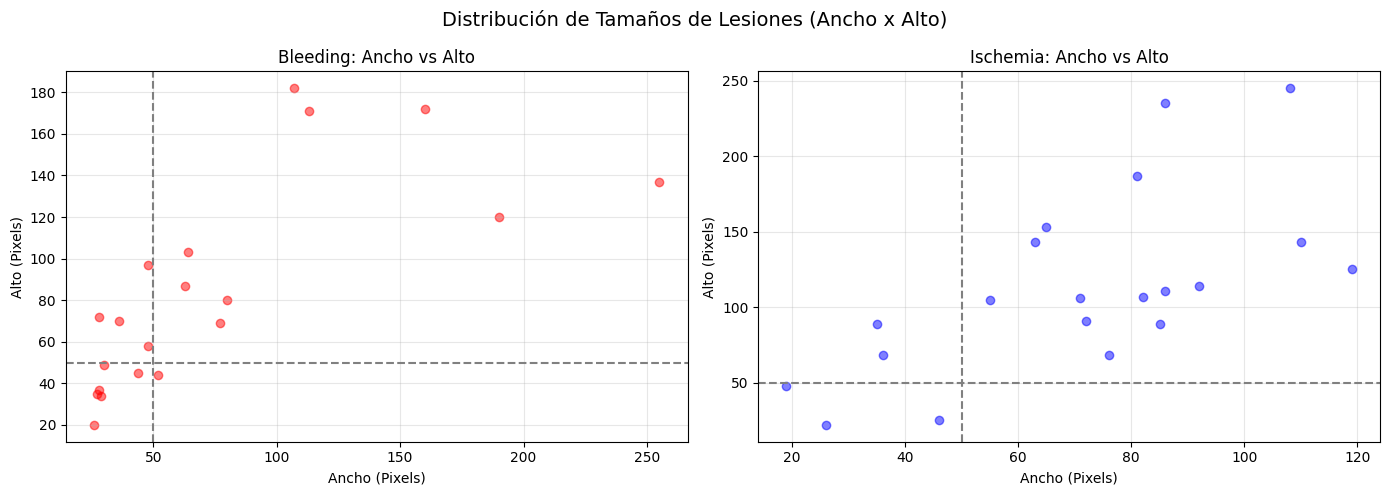

In [5]:
analyze_overlay_sizes(subdataset_filtered)

## Kernel Extractor
Obtengo Kernels de 32x32 de cada tejido:
- Normal: proviene de 'brain' (tejido sano).
- Ischemia/Bleeding: proviene de 'overlay' (tejido no sano).

In [8]:
from kernel_extraction.kernel_extractor import KernelExtractorManager
kernel_manager = KernelExtractorManager(subdataset_filtered)
kernels_dataset = kernel_manager.extract_all()

Iniciando extracción por componentes conectados (Lesion-Centric)...
  -> Minando lesiones completas de Bleeding...
  -> Minando lesiones completas de Ischemia...

Total patológico extraído: 150 Bleeding, 38 Ischemia.
  -> Procesando Normal: Buscando 188 parches con formas específicas...
--------------------------------------------------
RESUMEN DE KERNELS EXTRAÍDOS (TAMAÑOS VARIABLES):
[Bleeding]: 150 parches de dimensiones anatómicas variables.
[Ischemia]: 38 parches de dimensiones anatómicas variables.
[Normal]: 187 parches de dimensiones anatómicas variables.
--------------------------------------------------


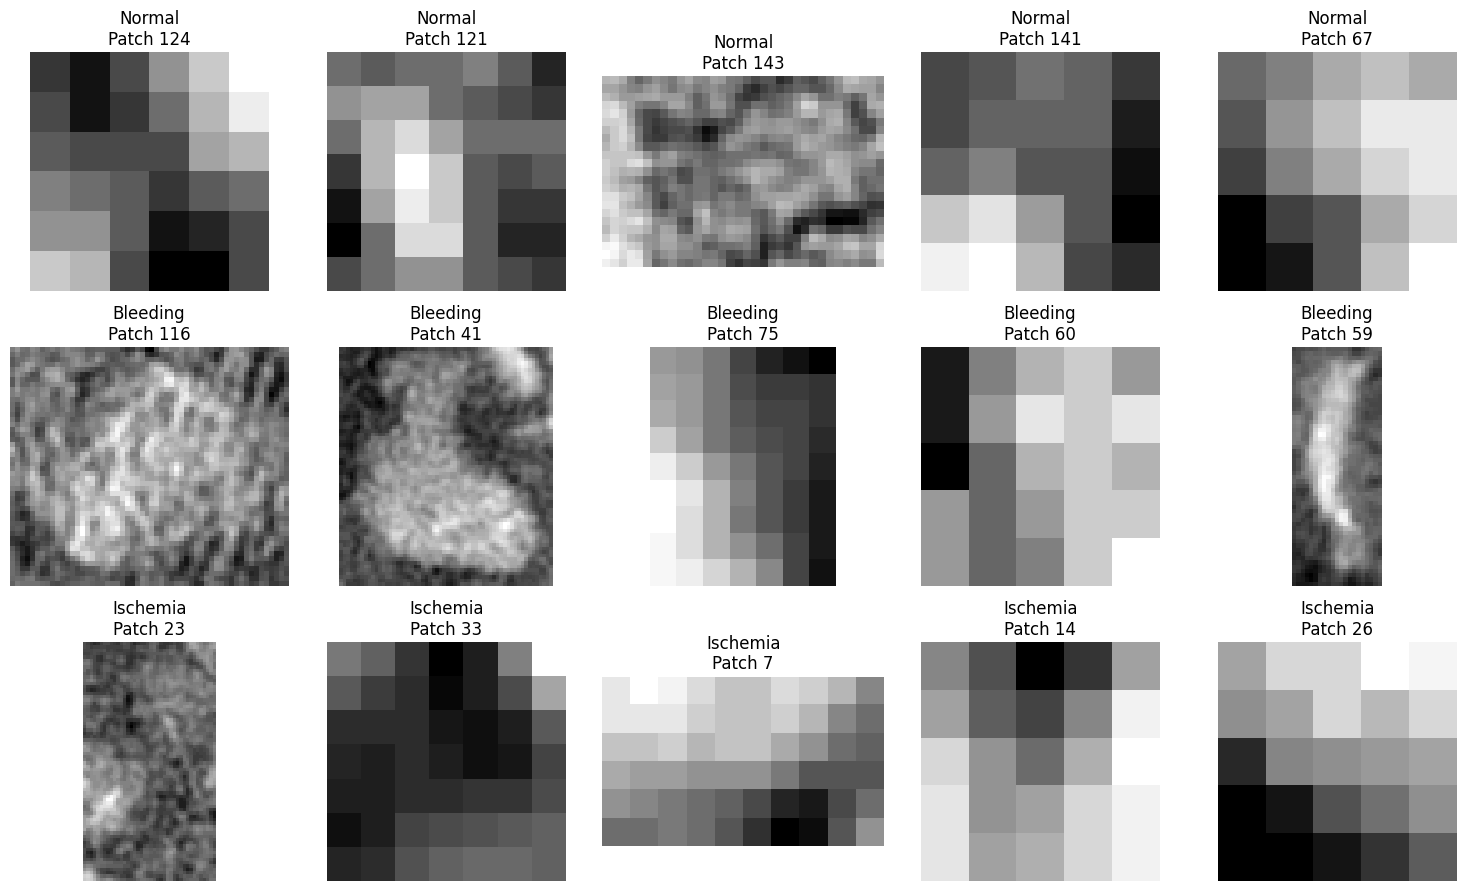

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
classes = ['Normal', 'Bleeding', 'Ischemia']

for row, cls in enumerate(classes):
    # Elegimos 5 parches al azar de la clase actual
    random_indices = np.random.choice(len(kernels_dataset[cls]), 5, replace=False)
    
    for col, idx in enumerate(random_indices):
        axes[row, col].imshow(kernels_dataset[cls][idx], cmap='gray')
        axes[row, col].set_title(f"{cls}\nPatch {idx}")
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()